# Aplikasi Deteksi Suara Buka-Tutup

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import os
import pandas as pd
from IPython.display import Audio, display

ModuleNotFoundError: No module named 'librosa'

In [127]:
data = "../dataset/"

input_base = data
output_base = "data_preprocessed"

os.makedirs(output_base, exist_ok=True)

In [128]:
def preprocess_audio(input_path, output_path, sr=16000):
    # Load audio
    y, _ = librosa.load(input_path, sr=sr)
    
    # Trim silence
    y_trimmed, _ = librosa.effects.trim(y, top_db=20)
    
    # Normalisasi amplitudo
    y_norm = y_trimmed / np.max(np.abs(y_trimmed))
    
    # Simpan
    sf.write(output_path, y_norm, sr)


In [129]:
rows = []

for name in ['Ardhi', 'Ilham']:
    temp = os.path.join(data, name)
    print(temp)
    for file_name in ["buka", "tutup"]:
        input_folder = os.path.join(temp, file_name)
        list_audio = os.listdir(input_folder)

        output_folder = os.path.join(output_base, name, file_name)
        os.makedirs(output_folder, exist_ok=True)

        for name_audio in list_audio:
            if name_audio.endswith(".wav"):
                from_path = os.path.join(input_folder, name_audio)
                clear_path = os.path.join(output_folder, name_audio)

                try:
                    preprocess_audio(from_path, clear_path)
                    rows.append({
                        "split": name_audio,
                        "speaker": name,
                        "label_command": file_name,
                        "file_path": clear_path
                    })
                except Exception as e:
                    print(f"Error {name_audio}: {e}")

metadata= pd.DataFrame(rows)
metadata.to_csv(output_base + "/metadata.csv", index=False)
print("done!")

../dataset/Ardhi
../dataset/Ilham
done!


Durasi sebelum preprocessing : 2.10 detik
Durasi sesudah preprocessing : 0.54 detik



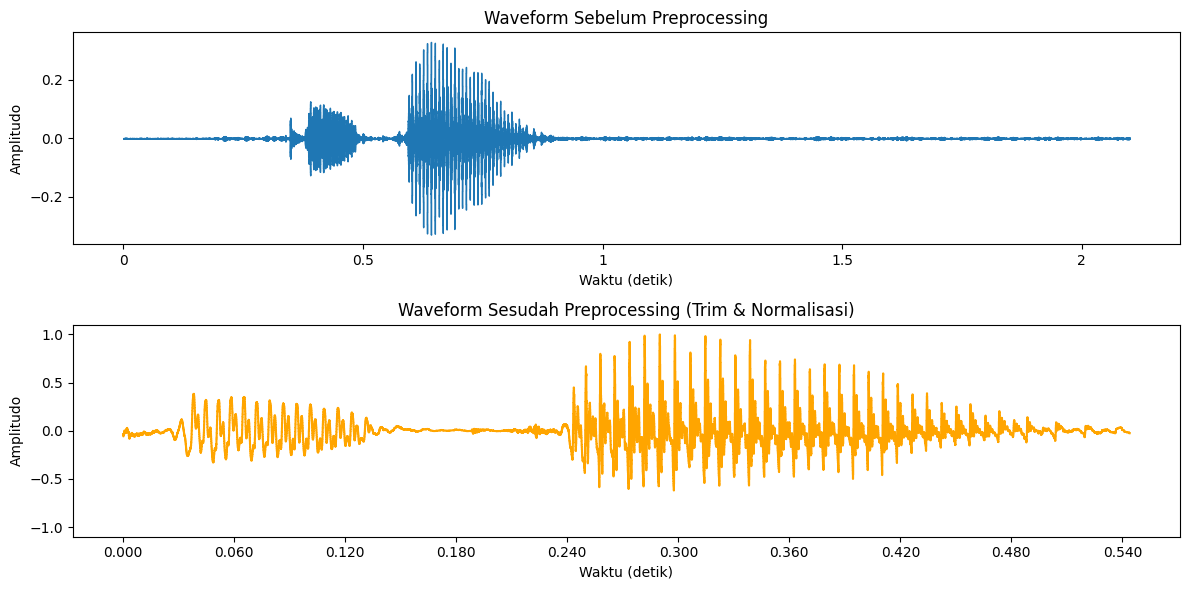

 Sebelum preprocessing:


 Sesudah preprocessing:


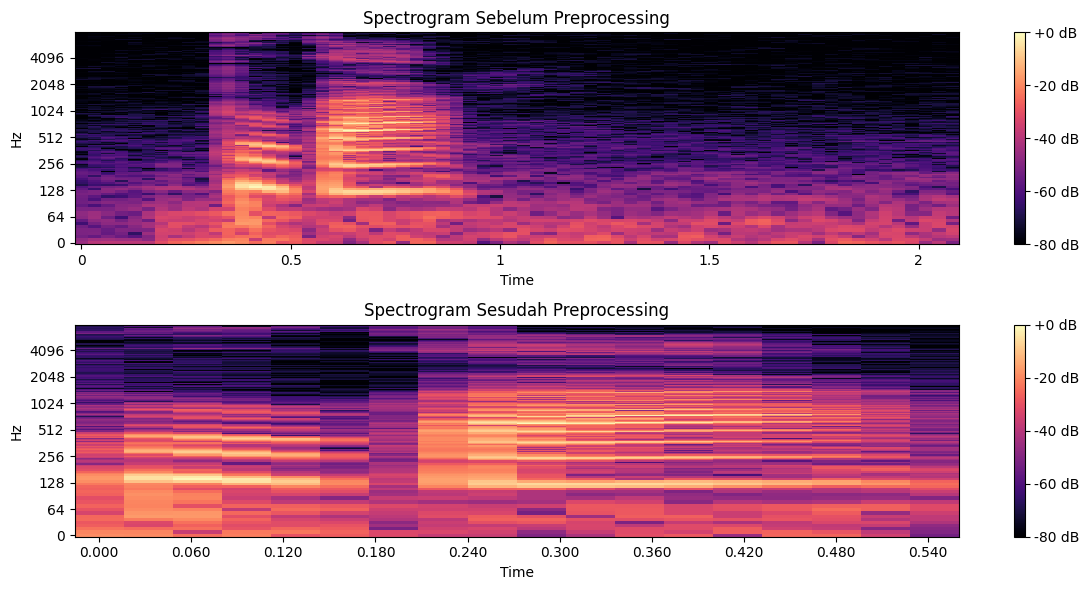

In [130]:
path = "Ardhi/buka"
preprocessed_file = os.path.join(output_base, path, os.listdir(os.path.join(output_base, "Ardhi", "buka"))[0])

original_file = os.path.join(data, path, os.listdir(os.path.join(data, "Ardhi", "buka"))[0])

y_orig, sr_orig = librosa.load(original_file, sr=16000)
y_proc, sr_proc = librosa.load(preprocessed_file, sr=16000)

durasi_asli = librosa.get_duration(y=y_orig, sr=sr_orig)
durasi_baru = librosa.get_duration(y=y_proc, sr=sr_proc)

print(f"Durasi sebelum preprocessing : {durasi_asli:.2f} detik")
print(f"Durasi sesudah preprocessing : {durasi_baru:.2f} detik\n")

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
librosa.display.waveshow(y_orig, sr=sr_orig)
plt.title("Waveform Sebelum Preprocessing")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")

plt.subplot(2, 1, 2)
librosa.display.waveshow(y_proc, sr=sr_proc, color='orange')
plt.title("Waveform Sesudah Preprocessing (Trim & Normalisasi)")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")

plt.tight_layout()
plt.show()

print(" Sebelum preprocessing:")
display(Audio(data=y_orig, rate=sr_orig))

print(" Sesudah preprocessing:")
display(Audio(data=y_proc, rate=sr_proc))

S_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_orig)), ref=np.max)
S_proc = librosa.amplitude_to_db(np.abs(librosa.stft(y_proc)), ref=np.max)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
librosa.display.specshow(S_orig, sr=sr_orig, x_axis='time', y_axis='log')
plt.colorbar(format="%+2.f dB")
plt.title("Spectrogram Sebelum Preprocessing")

plt.subplot(2, 1, 2)
librosa.display.specshow(S_proc, sr=sr_proc, x_axis='time', y_axis='log')
plt.colorbar(format="%+2.f dB")
plt.title("Spectrogram Sesudah Preprocessing")

plt.tight_layout()
plt.show()

## Ekstraksi Fitur

In [131]:
from scipy.stats import skew, kurtosis

def agg_stats(x):
    return {
        'mean': np.mean(x),
        'std': np.std(x),
        'median': np.median(x),
        'skew': skew(x) if len(x)>2 else 0.0,
        'kurtosis': kurtosis(x) if len(x)>2 else 0.0
    }

def extract_features(file_path, speaker, label_command):
    y, sr = librosa.load(file_path, sr=16000)  # atur sr sesuai dataset
    features = {}
    # temporal
    z = librosa.feature.zero_crossing_rate(y)[0]
    rms = librosa.feature.rms(y=y)[0]
    features.update({f'zcr_{k}':v for k,v in agg_stats(z).items()})
    features.update({f'rms_{k}':v for k,v in agg_stats(rms).items()})
    features['duration'] = len(y)/sr
    # spectral
    sc = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    sb = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    roll = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    spec_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)[0]
    flat = librosa.feature.spectral_flatness(y=y)[0]
    features.update({f'sc_{k}':v for k,v in agg_stats(sc).items()})
    features.update({f'sb_{k}':v for k,v in agg_stats(sb).items()})
    features.update({f'roll_{k}':v for k,v in agg_stats(roll).items()})
    features.update({f'contrast_{k}':v for k,v in agg_stats(spec_contrast).items()})
    features.update({f'flat_{k}':v for k,v in agg_stats(flat).items()})
    # mfcc (ambil beberapa koefisien, dan agregat per koef)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(mfcc.shape[0]):
        stats = agg_stats(mfcc[i])
        features.update({f'mfcc{i+1}_{k}':v for k,v in stats.items()})
    # f0 (pitch) -- gunakan yin jika cocok
    try:
        f0 = librosa.yin(y, fmin=50, fmax=500, sr=sr)
        features.update({f'f0_{k}':v for k,v in agg_stats(f0).items()})
    except Exception:
        features.update({'f0_mean':0.0, 'f0_std':0.0, 'f0_median':0.0, 'f0_skew':0.0, 'f0_kurtosis':0.0})

    features['speaker'] = speaker
    features['label_command'] = label_command
    return features

# loop folder
data = []
audio = pd.read_csv(output_base + "/metadata.csv")
for _, col in audio.iterrows():
    path_audio = col['file_path']
    data.append(extract_features(path_audio, col['speaker'], col['label_command']))

df = pd.DataFrame(data)
df.to_csv('features_all.csv', index=False)
print("Done, features shape:", df.shape)


Done, features shape: (209, 108)


In [132]:
df.isnull().sum()

zcr_mean         0
zcr_std          0
zcr_median       0
zcr_skew         0
zcr_kurtosis     0
                ..
f0_median        0
f0_skew          0
f0_kurtosis      0
speaker          0
label_command    0
Length: 108, dtype: int64

In [133]:
features_df = df.dropna()
features_df

,zcr_mean,zcr_std,zcr_median,zcr_skew,zcr_kurtosis,rms_mean,rms_std,rms_median,rms_skew,rms_kurtosis,...,mfcc13_median,mfcc13_skew,mfcc13_kurtosis,f0_mean,f0_std,f0_median,f0_skew,f0_kurtosis,speaker,label_command
0,0.066406,0.036590,0.074219,0.266045,-1.007885,0.141476,0.071303,0.137055,0.241846,-0.968193,...,-12.746545,0.153673,-1.321126,117.814430,30.225395,125.229853,-1.027453,-0.480100,Ardhi,buka
1,0.034249,0.019635,0.032715,0.695475,-0.162941,0.080697,0.078347,0.034281,0.787181,-1.000046,...,-1.425081,-0.283579,-1.232549,101.494119,73.673505,118.175752,2.607453,7.875975,Ardhi,buka
2,0.036075,0.028051,0.030273,0.673286,-0.507512,0.166975,0.113438,0.148707,0.535846,-0.768748,...,-4.048452,0.147343,-1.621186,100.806087,37.830698,127.149066,-0.326544,-1.796149,Ardhi,buka
3,0.063690,0.022897,0.055420,0.444862,-0.979073,0.120656,0.058592,0.140584,-0.531925,-1.077047,...,-0.378806,-0.250919,-1.277180,116.740087,29.752156,123.927215,-1.191240,0.002062,Ardhi,buka
4,0.033230,0.025858,0.024658,0.987282,-0.217836,0.108809,0.065065,0.108420,0.379502,-0.903493,...,-12.569832,-0.224211,-0.854477,139.669795,78.372450,131.304193,2.503793,7.203786,Ardhi,buka
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,0.068168,0.020738,0.066162,0.144146,-1.097207,0.105558,0.098723,0.040599,0.920048,-0.633789,...,-5.748257,-0.345785,-0.550809,111.623664,32.096976,105.887701,-0.501951,-0.697581,Ilham,tutup
205,0.052197,0.015312,0.047607,1.025966,-0.083108,0.127268,0.112172,0.045348,0.669119,-1.213032,...,-8.437258,-0.650226,-0.007173,114.824863,28.965674,127.685092,-1.008966,-0.065678,Ilham,tutup
206,0.063583,0.024135,0.059570,0.436692,-0.735422,0.118134,0.095551,0.094705,0.883161,-0.330500,...,-6.003295,0.131729,-0.720148,107.377005,24.810513,113.076610,-1.125503,1.062607,Ilham,tutup
207,0.059082,0.017727,0.052002,0.475348,-0.818485,0.149036,0.120153,0.083529,0.554595,-1.337751,...,-6.085682,-0.370648,-1.123505,113.860439,45.601378,124.943692,-0.319843,-1.568409,Ilham,tutup


In [134]:
features_df.isnull().sum()

zcr_mean         0
zcr_std          0
zcr_median       0
zcr_skew         0
zcr_kurtosis     0
                ..
f0_median        0
f0_skew          0
f0_kurtosis      0
speaker          0
label_command    0
Length: 108, dtype: int64

In [135]:
features_df.to_csv("data_suara.csv")

In [136]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

df = features_df
# buat label gabungan jika mau (speaker + command)
df['label_full'] = df['speaker'] + "_" + df['label_command']

# drop kolom non numeric
X = df.drop(columns=['speaker','label_command','label_full'])
# pastikan hanya numeric
X = X.select_dtypes(include=[np.number]).fillna(0)

# target (pilih target sesuai kebutuhan)
y = df['label_full']  # atau gunakan 'label_command' untuk hanya command

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Seleksi fitur

In [137]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# model untuk mendeteksi buka/tutup
y_command = LabelEncoder().fit_transform(df['label_command'])
X = df.drop(columns=['label_full','speaker', 'label_command'])

mi_command = mutual_info_classif(X, y_command, random_state=42)
mi_scores_command = pd.Series(mi_command, index=X.columns).sort_values(ascending=False)

selected_features_command  = mi_scores_command[mi_scores_command > 0.3].index.tolist()
print(selected_features_command )


['mfcc8_mean', 'mfcc8_median', 'mfcc11_mean', 'sc_mean', 'mfcc3_median']


In [138]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# model untuk mendeteksi buka/tutup
y_command = LabelEncoder().fit_transform(df['speaker'])
X = df.drop(columns=['label_full','speaker', 'label_command'])

mi_command = mutual_info_classif(X, y_command, random_state=42)
mi_scores_command = pd.Series(mi_command, index=X.columns).sort_values(ascending=False)

selected_features_speaker  = mi_scores_command[mi_scores_command > 0.3].index.tolist()
print(selected_features_speaker )

['mfcc3_mean', 'mfcc1_std', 'mfcc4_median', 'mfcc4_mean', 'mfcc3_median', 'contrast_mean', 'contrast_median', 'mfcc11_median', 'mfcc5_skew', 'mfcc7_std', 'flat_median', 'mfcc11_mean', 'f0_median', 'f0_std', 'mfcc3_std']


# modeling

In [139]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import pickle


In [140]:
df = pd.read_csv('features_all.csv')

# --- Command Model ---
X_command = df[['mfcc8_mean', 'mfcc8_median', 'mfcc11_mean', 'sc_mean', 'mfcc3_median']]
le_command = LabelEncoder()
y_command = le_command.fit_transform(df['label_command'])

# --- Speaker Model ---
X_speaker = df[['mfcc3_mean', 'mfcc1_std', 'mfcc4_median', 'mfcc4_mean', 'mfcc3_median',
                'contrast_mean', 'contrast_median', 'mfcc11_median', 'mfcc5_skew',
                'mfcc7_std', 'flat_median', 'mfcc11_mean', 'f0_median', 'f0_std', 'mfcc3_std']]
le_speaker = LabelEncoder()
y_speaker = le_speaker.fit_transform(df['speaker'])


In [141]:
scaler_command = StandardScaler()
X_command_scaled = scaler_command.fit_transform(X_command)

scaler_speaker = StandardScaler()
X_speaker_scaled = scaler_speaker.fit_transform(X_speaker)


In [142]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_command_scaled, y_command, test_size=0.3, random_state=42
)
model_command = RandomForestClassifier(random_state=42)
model_command.fit(Xc_train, yc_train)
print("Command Accuracy:", accuracy_score(yc_test, model_command.predict(Xc_test)))

# Simpan model dan scaler
with open("model_command.pkl", "wb") as f:
    pickle.dump(model_command, f)

with open("scaler_command.pkl", "wb") as f:
    pickle.dump(scaler_command, f)

with open("le_command.pkl", "wb") as f:
    pickle.dump(le_command, f)


Command Accuracy: 0.9682539682539683


In [143]:
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_speaker_scaled, y_speaker, test_size=0.3, random_state=42
)
model_speaker = RandomForestClassifier(random_state=42)
model_speaker.fit(Xs_train, ys_train)
print("Speaker Accuracy:", accuracy_score(ys_test, model_speaker.predict(Xs_test)))

with open("model_speaker.pkl", "wb") as f:
    pickle.dump(model_speaker, f)

with open("scaler_speaker.pkl", "wb") as f:
    pickle.dump(scaler_speaker, f)

with open("le_speaker.pkl", "wb") as f:
    pickle.dump(le_speaker, f)


Speaker Accuracy: 1.0


In [169]:
from scipy.stats import skew, kurtosis
import sounddevice as sd
import soundfile as sf
from IPython.display import Audio, display
# load model

le_command = pickle.load(open("le_command.pkl", "rb"))
model_command = pickle.load(open("model_command.pkl", "rb"))
scaler_command = pickle.load(open("scaler_command.pkl", "rb"))

le_speaker = pickle.load(open("le_speaker.pkl", "rb"))
model_speaker = pickle.load(open("model_speaker.pkl", "rb"))
scaler_speaker = pickle.load(open("scaler_speaker.pkl", "rb"))

file_path = "../dataset/testing/buka_ardhi_01.wav"

# file_path = "data_preprocessed/test/test1.wav" 
# # Rekam selama 3 detik
# duration = 2
# sr = 16000
# print("Mulai rekam...")
# recording = sd.rec(int(duration * sr), samplerate=sr, channels=1, dtype='float32')
# sd.wait()
# print("Rekaman selesai!")

# sf.write(file_path, recording, sr)


def agg_stats(x):
    return {
        'mean': np.mean(x),
        'std': np.std(x),
        'median': np.median(x),
        'skew': skew(x) if len(x)>2 else 0.0,
        'kurtosis': kurtosis(x) if len(x)>2 else 0.0
    }

def extract_features(file_path):
    sr = 16000
    y, _ = librosa.load(file_path, sr=sr)  
    display(Audio(data=y, rate=_))

    features = {}

    # temporal
    z = librosa.feature.zero_crossing_rate(y)[0]
    rms = librosa.feature.rms(y=y)[0]
    features.update({f'zcr_{k}':v for k,v in agg_stats(z).items()})
    features.update({f'rms_{k}':v for k,v in agg_stats(rms).items()})
    features['duration'] = len(y)/sr

    # spectral
    sc = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    sb = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    roll = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    spec_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)[0]
    flat = librosa.feature.spectral_flatness(y=y)[0]
    features.update({f'sc_{k}':v for k,v in agg_stats(sc).items()})
    features.update({f'sb_{k}':v for k,v in agg_stats(sb).items()})
    features.update({f'roll_{k}':v for k,v in agg_stats(roll).items()})
    features.update({f'contrast_{k}':v for k,v in agg_stats(spec_contrast).items()})
    features.update({f'flat_{k}':v for k,v in agg_stats(flat).items()})

    # mfcc (ambil beberapa koefisien, dan agregat per koef)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(mfcc.shape[0]):
        stats = agg_stats(mfcc[i])
        features.update({f'mfcc{i+1}_{k}':v for k,v in stats.items()})
    # f0 (pitch) -- gunakan yin jika cocok
    try:
        f0 = librosa.yin(y, fmin=50, fmax=500, sr=sr)
        features.update({f'f0_{k}':v for k,v in agg_stats(f0).items()})
    except Exception:
        features.update({'f0_mean':0.0, 'f0_std':0.0, 'f0_median':0.0, 'f0_skew':0.0, 'f0_kurtosis':0.0})

    return features

# loop folder
data = []

data.append(extract_features(file_path))

df = pd.DataFrame(data)
# Fitur penting untuk masing-masing model
selected_features_command = ['mfcc8_mean', 'mfcc8_median', 'mfcc11_mean', 'sc_mean', 'mfcc3_median']

selected_features_speaker = ['mfcc3_mean', 'mfcc1_std', 'mfcc4_median', 'mfcc4_mean', 'mfcc3_median',
                             'contrast_mean', 'contrast_median', 'mfcc11_median', 'mfcc5_skew',
                             'mfcc7_std', 'flat_median', 'mfcc11_mean', 'f0_median', 'f0_std', 'mfcc3_std']

X_command = df[selected_features_command]
X_speaker = df[selected_features_speaker]

X_command_scaled = scaler_command.transform(X_command)
X_speaker_scaled = scaler_speaker.transform(X_speaker)

pred_command = model_command.predict(X_command_scaled)[0]
pred_speaker = model_speaker.predict(X_speaker_scaled)[0]

pred_command_prob = model_command.predict_proba(X_command_scaled)[0]
confidence_command = max(pred_command_prob) * 100

pred_speaker_prob = model_speaker.predict_proba(X_speaker_scaled)[0]
confidence_speaker = max(pred_speaker_prob) * 100

label_command = le_command.inverse_transform([pred_command])[0]
speaker_label = le_speaker.inverse_transform([pred_speaker])[0]


THRESHOLD = 70 

print("\n🎧 HASIL PREDIKSI:")

if confidence_command >= THRESHOLD and confidence_speaker >= THRESHOLD:
    print(f"Dikenali sebagai : {speaker_label}")
    print(f"Identifikasi sebagai : {label_command}")

    print(f"Confidence command : {confidence_command:.2f}%")
    print(f"Confidence speaker : {confidence_speaker:.2f}%")

else:
    print("Suara tidak dikenali (bukan 2 orang yang terdaftar)")
    print(f"Confidence command hanya {confidence_command:.2f}% < {THRESHOLD}%")
    print(f"Confidence speaker hanya {confidence_speaker:.2f}% < {THRESHOLD}%")



🎧 HASIL PREDIKSI:
Suara tidak dikenali (bukan 2 orang yang terdaftar)
Confidence command hanya 75.00% < 70%
Confidence speaker hanya 59.00% < 70%


# Hasil Aplikasi

[Klik di sini untuk membuka aplikasi](https://deteksi-suara-buka-tutup-dan-pengenalan-v2.streamlit.app/)